# Exploring-Convolutional-Layers-Through-Data-and-Experiments
### Author : Roger Rodriguez

----

## Dataset: Fashion-MNIST

This notebook explores the role of convolutional layers in neural networks. We analyze how architectural decisions impact learning, performance, and inductive bias

### Import the Libraries

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models



Load the dataset

In [ ]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()


EDA

In [4]:
print("Training samples:", x_train.shape[0])
print("Test samples:", x_test.shape[0])
print("Image shape:", x_train.shape[1:])


NameError: name 'x_train' is not defined

Fashion-MNIST consists of 28 × 28 grayscale images belonging to 10 clothing classes.
The data set is balanced and small enough to fit in memory, making it suitable
for exploratory cN experiments

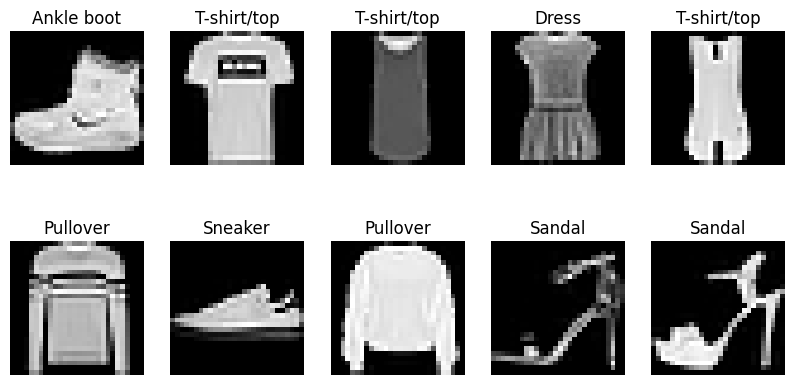

In [ ]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.show()


Visual inspection confirms that class identity depends on local spatial patterns
such as edges, contours and shapes, which motivates the use of convolutional layers

In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train_cnn = x_train[..., np.newaxis]
x_test_cnn = x_test[..., np.newaxis]


### Baseline Model

In [ ]:
baseline_model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])


c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


This model treats each pixel independently after flattening it, ignoring
Spatial relationships between neighborin pixels

Training Baseline

In [ ]:
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=2
)


Epoch 1/10
1500/1500 - 5s - 3ms/step - accuracy: 0.8163 - loss: 0.5170 - val_accuracy: 0.8356 - val_loss: 0.4460
Epoch 2/10
1500/1500 - 5s - 3ms/step - accuracy: 0.8600 - loss: 0.3807 - val_accuracy: 0.8637 - val_loss: 0.3762
Epoch 3/10
1500/1500 - 7s - 4ms/step - accuracy: 0.8734 - loss: 0.3403 - val_accuracy: 0.8759 - val_loss: 0.3459
Epoch 4/10
1500/1500 - 10s - 6ms/step - accuracy: 0.8832 - loss: 0.3149 - val_accuracy: 0.8764 - val_loss: 0.3472
Epoch 5/10
1500/1500 - 6s - 4ms/step - accuracy: 0.8886 - loss: 0.2985 - val_accuracy: 0.8748 - val_loss: 0.3437
Epoch 6/10
1500/1500 - 4s - 3ms/step - accuracy: 0.8936 - loss: 0.2824 - val_accuracy: 0.8834 - val_loss: 0.3271
Epoch 7/10
1500/1500 - 5s - 3ms/step - accuracy: 0.8987 - loss: 0.2689 - val_accuracy: 0.8838 - val_loss: 0.3325
Epoch 8/10
1500/1500 - 5s - 3ms/step - accuracy: 0.9020 - loss: 0.2591 - val_accuracy: 0.8852 - val_loss: 0.3210
Epoch 9/10
1500/1500 - 5s - 4ms/step - accuracy: 0.9059 - loss: 0.2476 - val_accuracy: 0.8873 -

Evaluate Baseline

In [ ]:
baseline_model.evaluate(x_test, y_test, verbose=0)


[0.35682737827301025, 0.8788999915122986]

Although the baseline achieves reasonable accuracy, it requires a large number
of parameters and lacks robustness to spatial transformations

### CNN Arquitecture Desing 

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), padding="same", activation="relu",
                  input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])


c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN

In [ ]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.fit(
    x_train_cnn, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=2
)


Epoch 1/10
1500/1500 - 15s - 10ms/step - accuracy: 0.8457 - loss: 0.4255 - val_accuracy: 0.8868 - val_loss: 0.3157
Epoch 2/10
1500/1500 - 13s - 9ms/step - accuracy: 0.8983 - loss: 0.2787 - val_accuracy: 0.8981 - val_loss: 0.2845
Epoch 3/10
1500/1500 - 14s - 9ms/step - accuracy: 0.9149 - loss: 0.2338 - val_accuracy: 0.8777 - val_loss: 0.3203
Epoch 4/10
1500/1500 - 19s - 12ms/step - accuracy: 0.9271 - loss: 0.2008 - val_accuracy: 0.9129 - val_loss: 0.2401
Epoch 5/10
1500/1500 - 22s - 15ms/step - accuracy: 0.9361 - loss: 0.1738 - val_accuracy: 0.9113 - val_loss: 0.2558
Epoch 6/10
1500/1500 - 21s - 14ms/step - accuracy: 0.9449 - loss: 0.1467 - val_accuracy: 0.9182 - val_loss: 0.2357
Epoch 7/10
1500/1500 - 16s - 11ms/step - accuracy: 0.9533 - loss: 0.1245 - val_accuracy: 0.9090 - val_loss: 0.2645
Epoch 8/10
1500/1500 - 23s - 15ms/step - accuracy: 0.9622 - loss: 0.1039 - val_accuracy: 0.9173 - val_loss: 0.2538
Epoch 9/10
1500/1500 - 16s - 11ms/step - accuracy: 0.9682 - loss: 0.0872 - val_acc

Evaluate CNN

In [ ]:
cnn_model.evaluate(x_test_cnn, y_test, verbose=0)


[0.3363993167877197, 0.9144999980926514]

### Controlled experiment: grain size

CNN With kernel 5x5

In [ ]:
cnn_5x5 = models.Sequential([
    layers.Conv2D(32, (5,5), padding="same", activation="relu",
                  input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (5,5), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])


Training and Evaluate

In [ ]:
cnn_5x5.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_5x5.fit(
    x_train_cnn, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=2
)

cnn_5x5.evaluate(x_test_cnn, y_test, verbose=0)


Epoch 1/10
1500/1500 - 20s - 13ms/step - accuracy: 0.9744 - loss: 0.0669 - val_accuracy: 0.9193 - val_loss: 0.3252
Epoch 2/10
1500/1500 - 18s - 12ms/step - accuracy: 0.9786 - loss: 0.0563 - val_accuracy: 0.9168 - val_loss: 0.3564
Epoch 3/10
1500/1500 - 17s - 11ms/step - accuracy: 0.9815 - loss: 0.0494 - val_accuracy: 0.9079 - val_loss: 0.3998
Epoch 4/10
1500/1500 - 32s - 22ms/step - accuracy: 0.9854 - loss: 0.0407 - val_accuracy: 0.9148 - val_loss: 0.4227
Epoch 5/10
1500/1500 - 19s - 12ms/step - accuracy: 0.9845 - loss: 0.0412 - val_accuracy: 0.9153 - val_loss: 0.4449
Epoch 6/10
1500/1500 - 18s - 12ms/step - accuracy: 0.9866 - loss: 0.0372 - val_accuracy: 0.9165 - val_loss: 0.5019
Epoch 7/10
1500/1500 - 38s - 25ms/step - accuracy: 0.9871 - loss: 0.0348 - val_accuracy: 0.9146 - val_loss: 0.4916
Epoch 8/10
1500/1500 - 49s - 33ms/step - accuracy: 0.9893 - loss: 0.0307 - val_accuracy: 0.9148 - val_loss: 0.5015
Epoch 9/10
1500/1500 - 46s - 31ms/step - accuracy: 0.9897 - loss: 0.0295 - val_a

[0.6423150897026062, 0.913100004196167]

Holding all other factors fixed, larger cores did not improve performance.
This highlights the efficiency of small grains combined with depth

### Interpretation

Convolutional layers outperform fully connected networks because they incorporate
prior assumptions about spatial structure directly into architecture    
This inductive bias reduces parameter counts, improves generalization,
and allows learning of hierarchical features
However, convolution is not appropriate for tabular or non-spatial data,
where locality assumptions are not met

Conclusion :
This study shows that architectural decisions, even simple ones,
have a significant impact on learning behavior
Understanding convolutional layers as inductive biases is key to
designing effective neural networks

EndPoint




In [3]:
cnn_model.save("fashion_cnn_model")
import sagemaker
from sagemaker.tensorflow import TensorFlowModel
role = sagemaker.get_execution_role()
model = TensorFlowModel(
    model_data="fashion_cnn_model",
    role=role,
    framework_version="2.15",
    sagemaker_session=sagemaker.Session()
)
predictor = model.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.large"
)


NameError: name 'cnn_model' is not defined

Prove the endpoint

In [ ]:
import numpy as np

sample = x_test_cnn[0]
sample = np.expand_dims(sample, axis=0)


Send endpoint 

In [ ]:
prediction = predictor.predict(sample)
predicted_class = np.argmax(prediction)

print("Predicted class:", predicted_class)
print("Label:", class_names[predicted_class])
predictor.delete_endpoint()


The trained CNN was deployed as a SageMaker endpoint using the TensorFlowModel abstraction.
The endpoint exposes the model as a managed inference service, enabling predictions on unseen images.
After verification, the endpoint was deleted to avoid unnecessary resource usage